In [17]:
import inspect
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from pvlib import iotools
from geomeppy import IDF
from extractepw import weather
from extractidf import zones, surfaces, windows, materials, occupancy
from init import init, justcsv, versioncheck
from alteridf import alteridf, alteridf_global
from bs4 import BeautifulSoup
import streamlit as st

In [18]:
st.write("Hello World")

2026-06-09 14:04:11.626 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 14:04:12.244 
  command:

    streamlit run C:\Users\annaa\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-09 14:04:12.245 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 14:04:12.246 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [19]:
denveridf = Path(r"C:\Users\annaa\Downloads\IISC\sim1\ASHRAE901_ApartmentHighRise_STD2019_Denver.idf")
denverepw = Path(r"C:\Users\annaa\Downloads\IISC\sim1\USA_CO_Denver.Intl.AP.725650_TMY3.epw")


newdelhiidf = Path(r"C:\Users\annaa\Downloads\IISC\sim2\ASHRAE901_OfficeLarge_STD2019_NewDelhi.idf")
newdelhiepw = Path(r"C:\Users\annaa\Downloads\IISC\sim2\IND_DL_New.Delhi-Gandhi.Intl.AP.421810_TMYx.2009-2023.epw")


IDD_PATH = Path(r"C:\EnergyPlusV26-1-1\Energy+.idd")

In [23]:
#idf = init(IDD_PATH, denveridf)
idf = init(IDD_PATH, newdelhiidf)
df_zones = zones(idf)

In [25]:
print(f"Total zones = {len(df_zones)}")
print("Dataframe Shape: ", df_zones.shape)
df_zones.iloc[:]

Total zones = 23
Dataframe Shape:  (23, 4)


,Zone_Index,Zone_Name,Direction_of_Relative_North,Multiplier
0,1,Basement,0.0,1.0000
1,2,Core_bottom,0.0,1.0000
2,3,Core_mid,0.0,10.0000
3,4,Core_top,0.0,1.0000
4,5,Perimeter_bot_ZN_3,0.0,1.0000
5,6,Perimeter_bot_ZN_2,0.0,1.0000
6,7,Perimeter_bot_ZN_1,0.0,1.0000
7,8,Perimeter_bot_ZN_4,0.0,1.0000
8,9,Perimeter_mid_ZN_3,0.0,10.0000
9,10,Perimeter_mid_ZN_2,0.0,10.0000


In [26]:
df_surfaces = surfaces(idf)

In [27]:
print(f"Total surfaces = {len(df_surfaces)}")
print("Dataframe Shappe: ", df_surfaces.shape)
df_surfaces.iloc[4:11]

Total surfaces = 151
Dataframe Shappe:  (151, 8)


,Surface_Name,Surface_Type,Zone_Name,Construction_Name,Area_m2,Azimuth_deg,Tilt_deg,Whats_Out
4,DataCenter_basement_ZN_6_Ceiling-Core_bot_ZN_5...,Floor,Core_bottom,int_slab_floor,419.300917,0.0,180.0,Surface
5,Core_bot_ZN_5_Wall_South,Wall,Core_bottom,int_wall,172.999322,180.0,90.0,Surface
6,Core_bot_ZN_5_Wall_West,Wall,Core_bottom,int_wall,108.639899,270.0,90.0,Surface
7,Core_bot_ZN_5_Wall_North,Wall,Core_bottom,int_wall,172.999322,0.0,90.0,Surface
8,Core_bot_ZN_5_Wall_East,Wall,Core_bottom,int_wall,108.639899,90.0,90.0,Surface
9,Core_mid_ZN_5_Ceiling,Ceiling,Core_mid,DropCeiling,2496.120460,0.0,0.0,Zone
10,Core_mid_ZN_5_Floor,Floor,Core_mid,int_slab_floor,2496.120460,0.0,180.0,Surface


In [28]:
df_windows = windows(idf)

In [29]:
print(f"Total windows = {len(df_windows)}")
print("Dataframe Shape: ", df_windows.shape)
df_windows.head()

Total windows = 24
Dataframe Shape:  (24, 5)


,Window_Name,Parent_Wall,Construction,Area_m2,Multiplier
0,Perimeter_bot_ZN_3_Wall_North_Window1,Perimeter_bot_ZN_3_Wall_North,Window_U_0.504_SHGC_North_0.229,23.179293,1
1,Perimeter_bot_ZN_3_Wall_North_Window2,Perimeter_bot_ZN_3_Wall_North,Window_U_0.504_SHGC_North_0.229,23.179293,1
2,Perimeter_bot_ZN_3_Wall_North_Window3,Perimeter_bot_ZN_3_Wall_North,Window_U_0.504_SHGC_North_0.229,23.179293,1
3,Perimeter_bot_ZN_3_Wall_North_Window4,Perimeter_bot_ZN_3_Wall_North,Window_U_0.504_SHGC_North_0.229,23.179293,1
4,Perimeter_bot_ZN_3_Wall_North_Window5,Perimeter_bot_ZN_3_Wall_North,Window_U_0.504_SHGC_North_0.229,23.178359,1


In [30]:
df_materials = materials(idf)

In [31]:
print(f"Totwl materials = {len(df_materials)}")
print(f"Dataframe Shape: ", df_materials.shape)
df_materials.iloc[:]

Totwl materials = 18
Dataframe Shape:  (18, 4)


,Material_Name,Thickness_mm,Conductivity_W_mK,Density_kg_m3
0,Std Wood 6inch,150.0,0.120,540.0
1,AC02 Acoustic Ceiling,12.7,0.057,288.0
2,F07 25mm stucco,25.4,0.720,1856.0
3,F08 Metal surface,0.8,45.280,7824.0
4,F08 Metal roof surface,0.8,45.280,7824.0
5,F12 Asphalt shingles,3.2,0.040,1120.0
6,F13 Built-up roofing,9.5,0.160,1120.0
7,G01 13mm gypsum board,12.7,0.160,800.0
8,G01 16mm gypsum board,15.9,0.160,800.0
9,G02 16mm plywood,15.9,0.120,544.0


In [32]:
df_people = occupancy(idf)

In [33]:
df_people.iloc[:]

,Occupancy_Name,Zone_or_Space_Name,Number_of_People_Schedule,Calculation_Method,Total_People_Count,People_per_Zone_Floor_Area,Floor_Area_per_Person_m2,Activity_Level_Schedule,Fraction_Radiant
0,DataCenter_bot_ZN_6,DataCenter_bot_ZN_6,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
1,DataCenter_mid_ZN_6,DataCenter_mid_ZN_6,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
2,DataCenter_top_ZN_6,DataCenter_top_ZN_6,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
3,DataCenter_basement_ZN_6,DataCenter_basement_ZN_6,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
4,Basement,Basement,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
5,Core_bottom,Core_bottom,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
6,Core_mid,Core_mid,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
7,Core_top,Core_top,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
8,Perimeter_bot_ZN_3,Perimeter_bot_ZN_3,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3
9,Perimeter_bot_ZN_2,Perimeter_bot_ZN_2,BLDG_OCC_SCH_wo_SB,Area/Person,NaN,NaN,18.578794,ACTIVITY_SCH,0.3


In [ ]:
df_weather = weather(denverepw)
#df_weather = weather(newdelhiepw)

In [ ]:
df_weather.describe()
df_weather.shape

In [6]:
idf.epw = str(denverepw)
#idf.epw = str(newdelhiepw)

outputdir = r"C:\Users\annaa\Downloads\IISC\sim1\sim_results"

In [ ]:
justcsv(idf, denverepw, outputdir)

In [ ]:
'''
all_tables = pd.read_html(str(r"C:\Users\annaa\Downloads\IISC\sim1\sim_results\eplustbl.htm"))
#all_tables = pd.read_html(str(r"C:\Users\annaa\Downloads\IISC\sim2\simresults\eplustbl.htm"))

print(f"{len(all_tables)}")
'''

In [ ]:
versioncheck(denveridf)

In [8]:
savedir = r"C:\Users\annaa\Downloads\IISC\sim1\modidf"
modidf = alteridf_global(idf, "people", 1.5, savedir, "globalpeople15.idf"  )

👥 Found 80 total PEOPLE objects. Scaling all entries...
📊 Global update complete. Scaled 80 occupancy zones by x1.5.
💾 File Success: Generated global modification archive at:
   C:\Users\annaa\Downloads\IISC\sim1\modidf\globalpeople15.idf


In [9]:
# Pass your modified model object straight to the simulation wrapper!
justcsv(
    idf_object=modidf, 
    weather_path=denverepw, 
    output_dir=r"C:\Users\annaa\Downloads\IISC\sim1\modidf"
)


C:\EnergyPlusV26-1-1\energyplus.exe --weather C:\Users\annaa\Downloads\IISC\sim1\USA_CO_Denver.Intl.AP.725650_TMY3.epw --output-directory C:\Users\annaa\Downloads\IISC\sim1\modidf --idd C:\EnergyPlusV26-1-1\Energy+.idd --readvars C:\Users\annaa\Downloads\IISC\sim1\modidf\globalpeople15_610eb1.idf



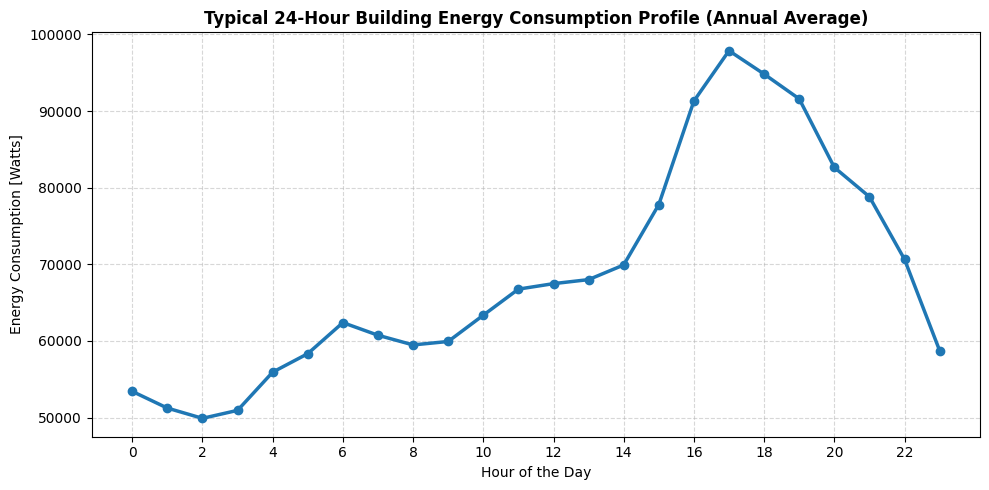

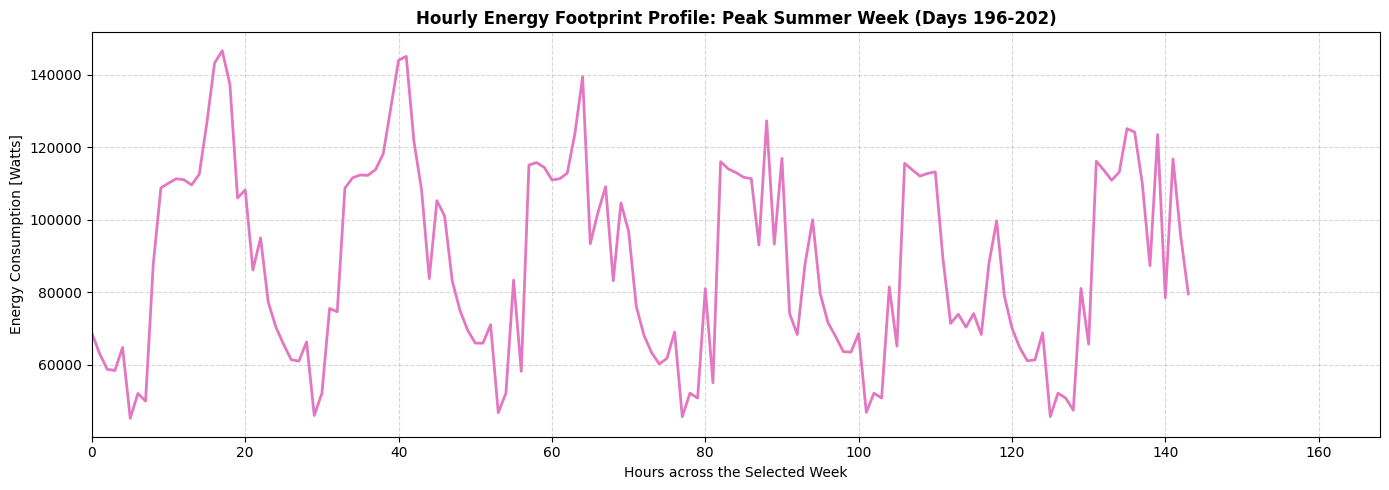

In [14]:
csv_path = Path(r"C:\Users\annaa\Downloads\IISC\sim1\sim_results\eplusout.csv")
df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

energy_col_matches = [col for col in df.columns if "Electricity Demand Rate" in col]

# Create basic time feature helpers based on 0-indexed rows (assuming a clean 8760 run)
energy_col = energy_col_matches[0]
df['Hour'] = df.index % 24
df['Day_of_Year'] = df.index // 24


plt.figure(figsize=(10, 5))

# Group by the hour and take the mean to get the typical diurnal cycle
diurnal_profile = df.groupby('Hour')[energy_col].mean()

plt.plot(diurnal_profile.index, diurnal_profile.values, color='#1f77b4', linewidth=2.5, marker='o')
plt.title('Typical 24-Hour Building Energy Consumption Profile (Annual Average)', fontsize=12, fontweight='bold')
plt.xlabel('Hour of the Day', fontsize=10)
plt.ylabel('Energy Consumption [Watts]', fontsize=10)
plt.xticks(range(0, 24, 2))  # Tick every 2 hours
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# --- OPTION B: Plotting a Critical Peak Summer Week (e.g., Mid-May) ---
# Days 135 to 142 roughly maps to a severe summer stretch in India
start_day = 196
end_day = 202

weekly_data = df[(df['Day_of_Year'] >= start_day) & (df['Day_of_Year'] < end_day)].copy()
weekly_data['Timeline_Hours'] = range(len(weekly_data))

plt.figure(figsize=(14, 5))
plt.plot(weekly_data['Timeline_Hours'], weekly_data[energy_col], color='#e377c2', linewidth=2)

# Styling the timeline ticks to represent daily boundaries cleanly
plt.title(f'Hourly Energy Footprint Profile: Peak Summer Week (Days {start_day}-{end_day})', fontsize=12, fontweight='bold')
plt.xlabel('Hours across the Selected Week', fontsize=10)
plt.ylabel('Energy Consumption [Watts]', fontsize=10)
plt.xlim(0, 168)  # Exactly 7 days
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

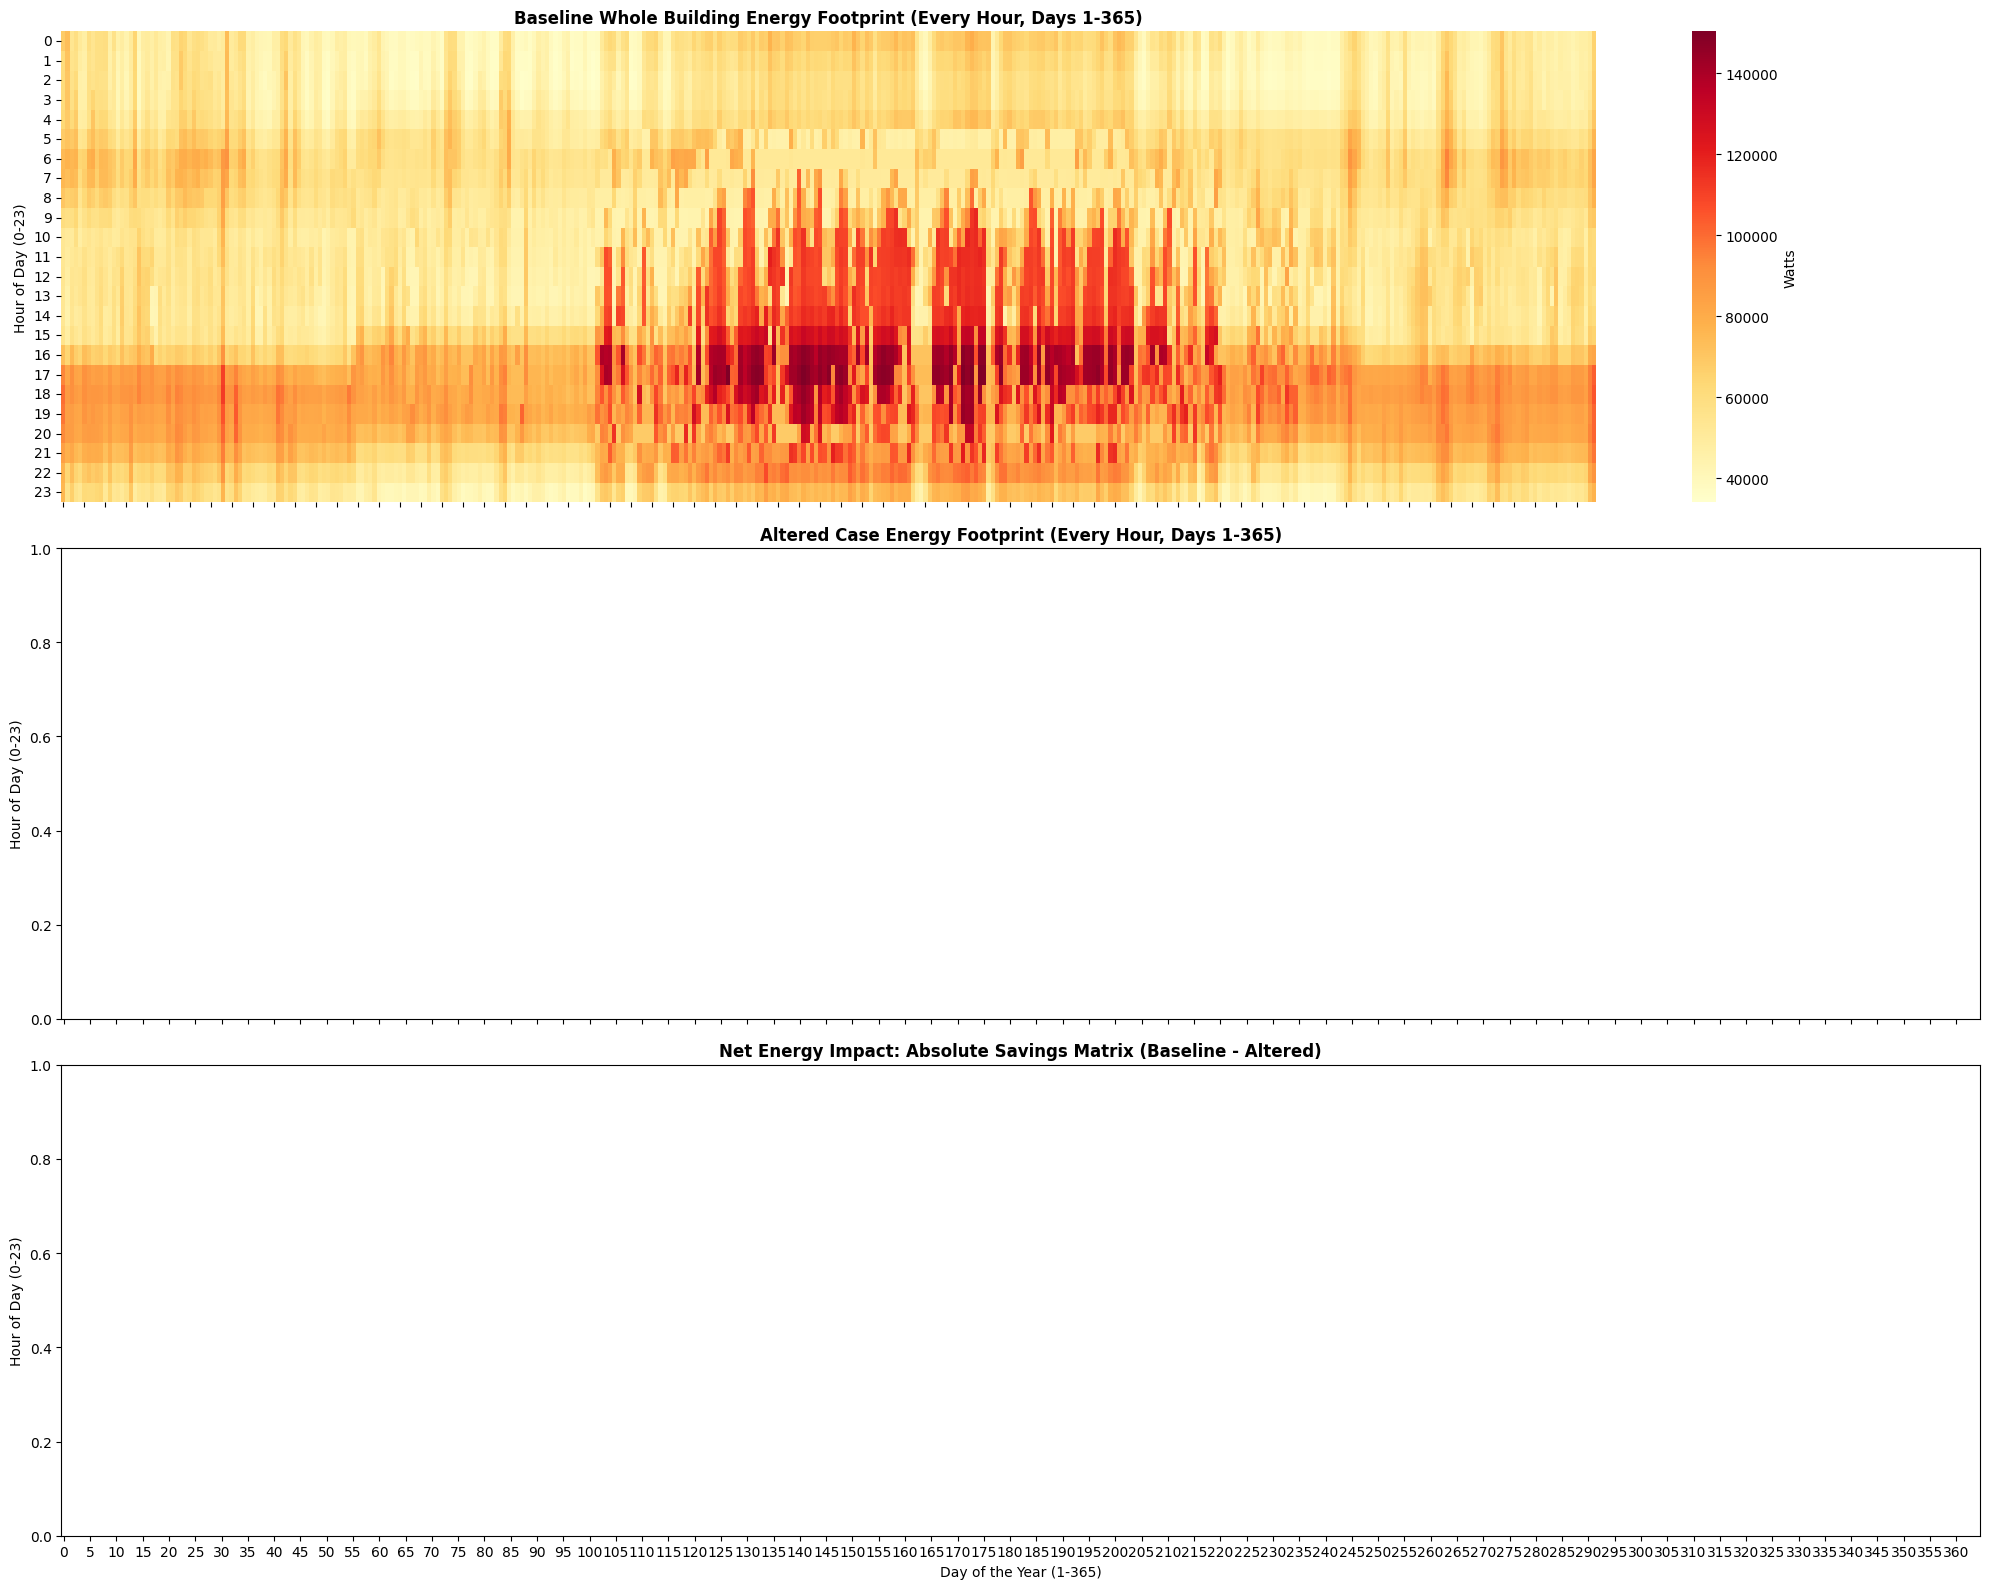

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the full 8760 datasets
df_base = pd.read_csv(r"C:\Users\annaa\Downloads\IISC\sim1\sim_results\eplusout.csv")
#df_alt = pd.read_csv(r"C:\Users\annaa\Downloads\IISC\sim2\sim_results\eplusout.csv")

# Clean whitespace from headers
df_base.columns = df_base.columns.str.strip()
#df_alt.columns = df_alt.columns.str.strip()

# Dynamically extract the target energy column
energy_col_base = [c for c in df_base.columns if "Electricity Demand Rate" in c][0]
#energy_col_alt = [c for c in df_alt.columns if "Electricity Demand Rate" in c][0]

# 2. Reshape the 8760 arrays into a (24 hours x 365 days) matrix
# EnergyPlus outputs data sequentially: Day 1 Hour 1, Day 1 Hour 2...
base_matrix = df_base[energy_col_base].values.reshape(365, 24).T
#alt_matrix = df_alt[energy_col_alt].values.reshape(365, 24).T

# Calculate the absolute difference matrix to isolate the change
#diff_matrix = base_matrix - alt_matrix

# 3. Plot the Entire Year Comparative Heatmaps
fig, axes = plt.subplots(3, 1, figsize=(20, 16), sharex=True)

# Graph A: Baseline Footprint
sns.heatmap(base_matrix, ax=axes[0], cmap='YlOrRd', cbar_kws={'label': 'Watts'})
axes[0].set_title('Baseline Whole Building Energy Footprint (Every Hour, Days 1-365)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Hour of Day (0-23)')

# Graph B: Altered Footprint
#sns.heatmap(alt_matrix, ax=axes[1], cmap='YlOrRd', cbar_kws={'label': 'Watts'})
axes[1].set_title('Altered Case Energy Footprint (Every Hour, Days 1-365)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Hour of Day (0-23)')

# Graph C: The Delta (Exactly where energy was saved)
#sns.heatmap(diff_matrix, ax=axes[2], cmap='Blues', cbar_kws={'label': 'Watts Saved'})
axes[2].set_title('Net Energy Impact: Absolute Savings Matrix (Baseline - Altered)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Day of the Year (1-365)')
axes[2].set_ylabel('Hour of Day (0-23)')

plt.tight_layout()
plt.show()

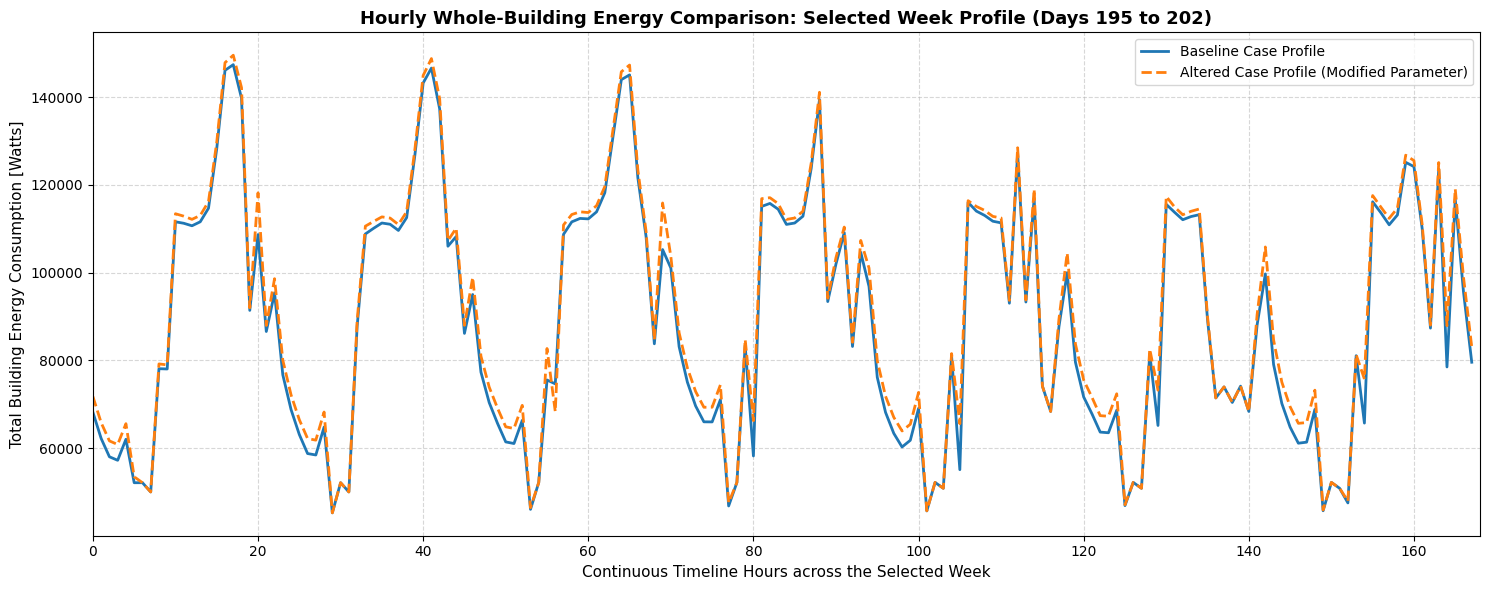

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- STEP 1: Load and Clean Both Datasets ---
# Path to your baseline results (sim1)
base_csv = Path(r"C:\Users\annaa\Downloads\IISC\sim1\sim_results\eplusout.csv")
df_base = pd.read_csv(base_csv)
df_base.columns = df_base.columns.str.strip()

# Path to your altered results (modidf folder)
alt_csv = Path(r"C:\Users\annaa\Downloads\IISC\sim1\modidf\eplusout.csv")
df_alt = pd.read_csv(alt_csv)
df_alt.columns = df_alt.columns.str.strip()

# Dynamically extract energy tracking columns to prevent string errors
energy_col_base = [col for col in df_base.columns if "Electricity Demand Rate" in col][0]
energy_col_alt = [col for col in df_alt.columns if "Electricity Demand Rate" in col][0]

# --- STEP 2: Establish Identical Chronological Metrics ---
for df in [df_base, df_alt]:
    df['Hour'] = df.index % 24
    df['Day_of_Year'] = df.index // 24

# =====================================================================
# 🛠️ CHOOSE YOUR ANALYSIS WEEK HERE
# =====================================================================
# Let's target a peak summer week (e.g., Days 195 to 202 is mid-July)
start_day = 195  
end_day = 202
# =====================================================================

# --- STEP 3: Filter Both Datasets to the Same Window ---
week_base = df_base[(df_base['Day_of_Year'] >= start_day) & (df_base['Day_of_Year'] < end_day)].copy()
week_alt = df_alt[(df_alt['Day_of_Year'] >= start_day) & (df_alt['Day_of_Year'] < end_day)].copy()

# Sync timelines sequentially from 0 to 168 hours
week_base['Timeline_Hours'] = range(len(week_base))
week_alt['Timeline_Hours'] = range(len(week_alt))

# --- STEP 4: Generate the Comparative Graph ---
plt.figure(figsize=(15, 6))

# Plot Baseline (Solid blue line)
plt.plot(
    week_base['Timeline_Hours'], 
    week_base[energy_col_base], 
    color='#1f77b4', 
    linewidth=2, 
    label='Baseline Case Profile'
)

# Plot Altered Variant (Dashed orange line overlay)
plt.plot(
    week_alt['Timeline_Hours'], 
    week_alt[energy_col_alt], 
    color='#ff7f0e', 
    linewidth=2, 
    linestyle='--', 
    label='Altered Case Profile (Modified Parameter)'
)

# --- STEP 5: Architecture and Formatting Rules ---
plt.title(f'Hourly Whole-Building Energy Comparison: Selected Week Profile (Days {start_day} to {end_day})', fontsize=13, fontweight='bold')
plt.xlabel('Continuous Timeline Hours across the Selected Week', fontsize=11)
plt.ylabel('Total Building Energy Consumption [Watts]', fontsize=11)

plt.xlim(0, 168)  # Clamp exactly to a 168-hour consecutive loop (7 Days)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()

# Run and showcase the graph
plt.show()

In [15]:
# Run this to get the exact numeric baseline vs altered metric
total_base_j = week_base[energy_col_base].sum() * 3600  # Convert rate back to total energy
total_alt_j = week_alt[energy_col_alt].sum() * 3600

kwh_base = total_base_j / 3600000
kwh_alt = total_alt_j / 3600000
delta_kwh = kwh_alt - kwh_base

print(f"Baseline Weekly Consumption: {kwh_base:.2f} kWh")
print(f"Altered Weekly Consumption:  {kwh_alt:.2f} kWh")
print(f"Absolute Increase:           {delta_kwh:.2f} kWh (+50.0% Occupancy Load)")

Baseline Weekly Consumption: 2198.15 kWh
Altered Weekly Consumption:  2253.20 kWh
Absolute Increase:           55.05 kWh (+50.0% Occupancy Load)
